<a href="https://colab.research.google.com/github/noobylub/Dissertation_Project/blob/master/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Check what device I am running on, and I want to make sure I am running on TPU
import torch

def check_gpu():
    """Check GPU availability"""
    if torch.cuda.is_available():
        print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
        return torch.device("cuda")


    else:
        print("📱 Using CPU")
        return torch.device("cpu")

device = check_gpu()

✅ GPU: Tesla T4


In [3]:
!pip install pandas
# Install bitsandbytes for quantisation
!pip install -U bitsandbytes>=0.46.1


# **Loading English Dataset**
In this section, we load the English Dataset for vector extraction later on

**Running in Colab Website**

In [3]:
# Loading GoEmotion Dataset and the module used to analyse them
!wget -P data/full_dataset/ https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv
!pip install pandas

--2026-03-18 15:07:17--  https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.26.207, 172.217.204.207, 172.217.203.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.26.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14173154 (14M) [application/octet-stream]
Saving to: ‘data/full_dataset/goemotions_2.csv’

goemotions_2.csv    100%[===================>]  13.52M  --.-KB/s    in 0.1s    

2026-03-18 15:07:18 (132 MB/s) - ‘data/full_dataset/goemotions_2.csv’ saved [14173154/14173154]



In [4]:
# Preliminary analysis
import pandas as pd
# Analysing from google colab
data_path = "/content/data/full_dataset/goemotions_2.csv"
df = pd.read_csv(data_path)
for contents in df.columns:
  print(contents)

text
id
author
subreddit
link_id
parent_id
created_utc
rater_id
example_very_unclear
admiration
amusement
anger
annoyance
approval
caring
confusion
curiosity
desire
disappointment
disapproval
disgust
embarrassment
excitement
fear
gratitude
grief
joy
love
nervousness
optimism
pride
realization
relief
remorse
sadness
surprise
neutral


**Running in Code Editor**


In [5]:
# Preliminary analysis
import pandas as pd
# Analysing from google colab
data_path = "./en_emotion/goemotions_2.csv"

df = pd.read_csv(data_path)
for contents in df.columns:
  print(contents)

text
id
author
subreddit
link_id
parent_id
created_utc
rater_id
example_very_unclear
admiration
amusement
anger
annoyance
approval
caring
confusion
curiosity
desire
disappointment
disapproval
disgust
embarrassment
excitement
fear
gratitude
grief
joy
love
nervousness
optimism
pride
realization
relief
remorse
sadness
surprise
neutral


Love, Happiness, Anger, Fear, Sadness

In [9]:
anger_statement = [row_data['text'] for index, row_data in df.iterrows() if row_data['anger'] == 1]
happiness_statement = [row_data['text'] for index, row_data in df.iterrows() if row_data['joy'] == 1]
sadness_statement = [row_data['text'] for index, row_data in df.iterrows() if row_data['sadness'] == 1]
love_statement = [row_data['text'] for index, row_data in df.iterrows() if row_data['love'] == 1]
fear_statement = [row_data['text'] for index, row_data in df.iterrows() if row_data['fear'] == 1]
fear_statement = [row_data['text'] for index, row_data in df.iterrows() if row_data['fear'] == 1]
neutral_statement = []
# Very Neutral statements 
with open('./en_emotion/NeutralData_Clean.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            neutral_statement.append(line)


print(f"Anger statements: {len(anger_statement)}")
print(f"Happiness statements: {len(happiness_statement)}")
print(f"Sadness statements: {len(sadness_statement)}")
print(f"Love statements: {len(love_statement)}")
print(f"Fear statements: {len(fear_statement)}")

Anger statements: 2762
Happiness statements: 2655
Sadness statements: 2228
Love statements: 2697
Fear statements: 1067


In [7]:
for index, happiness_statement in enumerate(happiness_statement):
  print(f"Index {index}: Happiness Statement {happiness_statement}")

for index, anger_statement in enumerate(anger_statement):
  print(f"Index {index}: Anger Statement {anger_statement}")

for index, sadness_statement in enumerate(sadness_statement):
  print(f"Index {index}: Sadness Statement {sadness_statement}")

for index, love_statement in enumerate(love_statement):
  print(f"Index {index}: Love Statement {love_statement}")

for index, fear_statement in enumerate(fear_statement):
  print(f"Index {index}: Fear Statement {fear_statement}")

Index 0: Happiness Statement hey, that's me. Glad i'm done with the class, so much work
Index 1: Happiness Statement I think everyone would enjoy it more if you did
Index 2: Happiness Statement Really glad you were there for her. I wish you both the best.
Index 3: Happiness Statement But now we're stressed out.
Index 4: Happiness Statement Yep, hell of a listener
Index 5: Happiness Statement It's weird how quickly I agreed with you. Usually I'da been more incredulous.
Index 6: Happiness Statement You get a lot more freedom and free time. College is a blast
Index 7: Happiness Statement Cheers! Let's keep it going!
Index 8: Happiness Statement Hey if any are left, I'd like to happily donate!
Index 9: Happiness Statement Man that’s cool, I like this sub. You’re a cool mod
Index 10: Happiness Statement Reading this made me pretty damn happy. Congrats hope it works out for you two.
Index 11: Happiness Statement I'm glad you had such a positive experience on the sub and congrats on the relat

In [ ]:
for index, neutral_stmt in enumerate(neutral_statement):
  print(f"Index {index}: Neutral Statement {neutral_stmt}")

**Select certain index, which contains statements with clearest example of the respective emotion**
<br/>
Retrieved by pasting the entire statements into an LLM, deepseek, with the prompt
- Give me the indices of the 50 most {emotion} statement from this list, and put them into an array, and also output the result


In [12]:
# neutral_indices = [
#     13263, 13267, 13269, 13277, 13287, 13288, 13296, 13309, 13321, 13326, 13335, 13348, 13356, 13360, 13365, 13378,
#     13394, 13407, 13420, 13445, 13460, 13476, 13494, 13511, 13526, 13540, 13551, 13573, 13600, 13628, 13646, 13655,
#     13694, 13723, 13726, 13741, 13753, 13784, 13820, 13845, 13865, 13892, 13923, 13927, 13948, 13960, 13986, 14020,
#     14025, 14034
# ]
fear_indices = [0, 5, 11, 21, 23, 25, 44, 47, 54, 68, 69, 75, 98, 109, 120, 128, 129, 130, 131, 133, 135, 138, 143, 152, 153, 171, 178, 188, 191, 209, 217, 230, 232, 233, 239, 240, 249, 251, 257, 258, 263, 279, 297, 300, 305, 324, 325, 331, 339, 344]
love_indices = [0, 1, 2, 3, 5, 9, 12, 13, 14, 16, 19, 24, 27, 28, 29, 36, 39, 45, 50, 52, 53, 56, 57, 58, 59, 62, 64, 67, 70, 71, 72, 73, 76, 77, 78, 79, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91, 94, 95, 96, 99]
anger_indices = [4, 10, 21, 26, 27, 28, 42, 59, 64, 89, 96, 105, 109, 150, 157, 159, 196, 197, 198, 223, 247, 252, 253, 264, 275, 277, 285, 290, 318, 339, 344, 356, 361, 368, 396, 412, 446, 453, 477, 479, 508, 513, 573, 589, 621, 636, 671, 677, 706, 736]
happiness_indices = [2, 7, 8, 10, 11, 19, 26, 29, 33, 45, 58, 80, 81, 86, 95, 101, 123, 128, 137, 148, 155, 168, 170, 182, 202, 209, 222, 223, 226, 231, 248, 250, 261, 275, 291, 296, 298, 313, 340, 346, 347, 363, 396, 398, 422, 440, 465, 500, 507, 635]
sadness_indices = [993, 994, 996, 1006, 1011, 1012, 1015, 1019, 1020, 1021, 1022, 1026, 1029, 1030, 1032, 1034, 1035, 1037, 1038, 1039, 1040, 1041, 1044, 1045, 1046, 1047, 1048, 1049, 1052, 1053, 1054, 1056, 1057, 1059, 1062, 1066, 1067, 1069, 1073, 1075, 1076, 1077, 1081, 1082, 1083, 1087, 1088, 1089, 1090, 1091, 1096, 1097]

neutral_texts = neutral_statement[:50]
anger_texts = [anger_statement[idx] for idx in anger_indices]
happiness_texts = [happiness_statement[idx] for idx in happiness_indices]
sadness_texts = [sadness_statement[idx] for idx in sadness_indices]
love_texts = [love_statement[idx] for idx in love_indices]
fear_texts = [fear_statement[idx] for idx in fear_indices]

In [13]:
print("NEUTRAL TEXTS:")
for i, text in enumerate(neutral_texts):
  print(f"{i}: {text}")

print("\nANGER TEXTS:")
for i, text in enumerate(anger_texts):
  print(f"{i}: {text}")

print("\nHAPPINESS TEXTS:")
for i, text in enumerate(happiness_texts):
  print(f"{i}: {text}")

print("\nSADNESS TEXTS:")
for i, text in enumerate(sadness_texts):
  print(f"{i}: {text}")

print("\nLOVE TEXTS:")
for i, text in enumerate(love_texts):
  print(f"{i}: {text}")

print("\nFEAR TEXTS:")
for i, text in enumerate(fear_texts):
  print(f"{i}: {text}")

NEUTRAL TEXTS:
0: The Earth orbits around the Sun.
1: Water boils at 100 degrees Celsius at sea level.
2: Paris is the capital of France.
3: The human body has 206 bones in adulthood.
4: Photosynthesis is the process by which plants convert sunlight into chemical energy.
5: The Great Wall of China is approximately 13,000 miles long.
6: Oxygen is essential for respiration in most living organisms.
7: The periodic table contains 118 known elements.
8: Mount Everest is the tallest mountain on Earth.
9: The Amazon rainforest covers an area of approximately 5.5 million square kilometers.
10: Light travels at approximately 299,792 kilometers per second.
11: The human heart pumps blood throughout the body.
12: Gravity is a fundamental force that attracts objects with mass.
13: The Nile River is the longest river in Africa.
14: DNA contains the genetic instructions for life.
15: The atmosphere is composed primarily of nitrogen and oxygen.
16: Photosynthesis produces oxygen as a byproduct.
17: 

# **Loading Indonesian Dataset**
In this section, we load the Indonesian Dataset for vector extraction later on

**Loading in Colab Website**

In [ ]:
import pandas as pd
# Analysing from google colab
anger_path = "/content/AngerData.csv"
happiness_path = "/content/JoyData.csv"
neuutral_path = "/content/NeutralData.csv"
anger_df = pd.read_csv(anger_path, sep='\t')
happiness_df = pd.read_csv(happiness_path, sep='\t')

for contents in anger_df.columns:
  print(contents)
for contents in happiness_df.columns:
  print(contents)

Tweet
Label
Tweet
Label


**Loading in IDE**

In [ ]:
import pandas as pd
# Analysing from google colab
anger_path = "./id_emotion/AngerData.txt"
happiness_path = "./id_emotion/JoyData.csv"
neutral_path = "./id_emotion/NeutralData.csv"
anger_df = pd.read_csv(anger_path, sep='\t')
happiness_df = pd.read_csv(happiness_path, sep='\t')
neutral_df = pd.read_csv(neutral_path, sep='\t')

for contents in anger_df.columns:
  print(contents)
for contents in happiness_df.columns:
  print(contents)

Tweet
Label
Tweet
Label


In [ ]:
anger_statements_id = [row_data['Tweet'] for index, row_data in anger_df.iterrows() ]
happiness_statements_id = [row_data['Tweet'] for index, row_data in happiness_df.iterrows() ]
neutral_statements_id = [row_data['Tweet'] for index, row_data in neutral_df.iterrows() ]

In [ ]:
for idx, happiness_statement in enumerate(happiness_statements_id):
  print("Happiness Statement at", idx, happiness_statement)

In [ ]:
for idx,anger_statement in enumerate(anger_statements_id):
  print("Anger Statement at " ,idx, anger_statement)

# **HuggingFace and Model Setup**

**Running through Google Colab**

In [ ]:
# If running on google colab website
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')

**Running through IDE**

In [ ]:
from dotenv import load_dotenv
import os

# Load the .env file (adjust path if needed)
load_dotenv('.env')

# Now access the variables
hf_token = os.getenv('HF_TOKEN')
print(hf_token)

Use these models: https://huggingface.co/google/gemma-7b
<br/>
Second model to test: https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct

In [28]:
# Lading the transformer models into the GPU

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Quantisation
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
)

# Trying to run inference on Llama 3.1 model
# Add device mapping and quantization
model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    token=hf_token,
    padding_side='left',


)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    token=hf_token,
    device_map="auto",           # Auto device placement
    quantization_config=bnb_config
)

ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

In [ ]:
import torch

def get_model_size(model):
    param_size = 0
    buffer_size = 0

    for param in model.parameters():
        param_size += param.nelement() * param.element_size()

    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    total_size = (param_size + buffer_size) / 1024**3  # GB

    print(f"Parameters: {param_size / 1024**3:.2f} GB")
    print(f"Buffers: {buffer_size / 1024**3:.2f} GB")
    print(f"Total: {total_size:.2f} GB")

    return total_size

# Check your model size
model_size_gb = get_model_size(model)

Parameters: 8.46 GB
Buffers: 0.00 GB
Total: 8.46 GB


In [ ]:
def hook_extract_vector(module, input, output):
    if isinstance(output, tuple):
        hidden_state = output[0]
    else:
        hidden_state = output  # Fixed: was output.last_hidden_state

    extracted_activations.append(hidden_state.detach().cpu())
    return output

print("Hook function redefined!")

Hook function redefined!


In [ ]:
model.model._forward_hooks.clear()

# **Vector Extraction**
We mostly follow this method: https://elib.dlr.de/218629/1/The_Effectiveness_of_Style_Vectors_for_Steering_Large_Language_Models_A_Human_Evaluation.pdf
<br/>
One critical aspect to note is we pass forward pass and extract the activaiton from that forward pass


In [27]:
# This is for extracting vectors
# We mostly follow this method: https://elib.dlr.de/218629/1/The_Effectiveness_of_Style_Vectors_for_Steering_Large_Language_Models_A_Human_Evaluation.pdf
# Extracting the input representation and averaging them to determine layer representation

import torch


# model generates with the given prompt and extracts the vectors
def generate_extract(user_text: str, model, tokenizer, max_new_tokens=200, layer_idx=15):

    messages = [
        {"role": "user", "content": user_text},

    ]

    encoded_inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)


    with torch.no_grad():
        outputs = model(
            **encoded_inputs,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            output_hidden_states = True,
        )
        # output = model(**inputs)
        # outputs = output

    # input_length = input_ids.shape[1]
    # generated_text = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)
    # print(generated_text)

    # extract_hook.remove()
    # Take mean generated vector so we can compress into one


    return torch.mean(torch.stack(outputs.hidden_states),dim=0)

# **Activation Steering**
You can apply to specific layers, or all layers 

In [ ]:
import torch

def extract_vector_with_steering(module, input, output, steering_vector, strength):
    """
    Extract hidden states and apply steering vector modification.

    Args:
        steering_vector: The steering vector to apply (e.g., anger_steering)
        strength: Scalar multiplier for steering strength (0.0 to 1.0+)
    """
    if isinstance(output, tuple):
        hidden_state = output[0]
    else:
        hidden_state = output

    steered_output = hidden_state + (steering_vector.unsqueeze(0).unsqueeze(0) * strength)

    return steered_output


def generate_with_steering(
    user_text: str,
    system_text: str,
    model,
    tokenizer,
    steering_vector=None,
    steering_strength=1.0,
    max_new_tokens=200,
    temperature=0.7,
    do_sample=True
):
    """
    Generate text with optional steering vector applied to ALL layers.

    Args:
        user_text: User prompt
        system_text: System prompt
        model: Language model
        tokenizer: Tokenizer
        steering_vector: Steering vector to apply (None for no steering)
        steering_strength: Strength of steering (0.0 = no effect, 1.0 = full effect, >1.0 = amplified)
        max_new_tokens: Max tokens to generate
        temperature: Sampling temperature
        do_sample: Whether to use sampling

    Returns:
        generated_text: The generated text
    """

    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": user_text}
    ]

    encoded_inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)

    input_ids = encoded_inputs["input_ids"]
    attention_mask = encoded_inputs["attention_mask"]

    hook_handles = []
    if steering_vector is not None:
        def hook_fn(module, input, output):
            return extract_vector_with_steering(module, input, output, steering_vector, steering_strength)

        # Register hook on ALL layers
        num_layers = len(model.model.layers)
        for layer_idx in range(num_layers):
            handle = model.model.layers[layer_idx].register_forward_hook(hook_fn)
            hook_handles.append(handle)

        print(f"Applied steering to all {num_layers} layers with strength {steering_strength}")

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=do_sample,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Remove all hooks
    for handle in hook_handles:
        handle.remove()

    input_length = input_ids.shape[1]
    generated_text = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)

    return generated_text

**Passing text with certain emotions through LLM**

In [18]:
import random

# Set seed for reproducibility
random.seed(42)

# Sample 10 texts from each emotion (50 total) + all neutral texts
sampled_anger = random.sample(anger_texts, min(10, len(anger_texts)))
sampled_happiness = random.sample(happiness_texts, min(10, len(happiness_texts)))
sampled_sadness = random.sample(sadness_texts, min(10, len(sadness_texts)))
sampled_love = random.sample(love_texts, min(10, len(love_texts)))
sampled_fear = random.sample(fear_texts, min(10, len(fear_texts)))

# Combine all into expanded neutral texts
expanded_neutral_texts = neutral_texts + sampled_anger + sampled_happiness + sampled_sadness + sampled_love + sampled_fear

print(f"Original neutral texts: {len(neutral_texts)}")
print(f"Sampled anger: {len(sampled_anger)}")
print(f"Sampled happiness: {len(sampled_happiness)}")
print(f"Sampled sadness: {len(sampled_sadness)}")
print(f"Sampled love: {len(sampled_love)}")
print(f"Sampled fear: {len(sampled_fear)}")
print(f"\nTotal expanded neutral texts: {len(expanded_neutral_texts)}")

Original neutral texts: 50
Sampled anger: 10
Sampled happiness: 10
Sampled sadness: 10
Sampled love: 10
Sampled fear: 10

Total expanded neutral texts: 100


In [ ]:
# Prompts designed to ellicity joy emotion

print(neutral_prompts)

for p in happiness_prompts:
    print(p)
print("====="*20)
for a in anger_prompts:
    print(a)



['The Earth orbits around the Sun.', 'Water boils at 100 degrees Celsius at sea level.', 'Paris is the capital of France.', 'The human body has 206 bones in adulthood.', 'Photosynthesis is the process by which plants convert sunlight into chemical energy.', 'The Great Wall of China is approximately 13,000 miles long.', 'Oxygen is essential for respiration in most living organisms.', 'The periodic table contains 118 known elements.', 'Mount Everest is the tallest mountain on Earth.', 'The Amazon rainforest covers an area of approximately 5.5 million square kilometers.', 'Light travels at approximately 299,792 kilometers per second.', 'The human heart pumps blood throughout the body.', 'Gravity is a fundamental force that attracts objects with mass.', 'The Nile River is the longest river in Africa.', 'DNA contains the genetic instructions for life.', 'The atmosphere is composed primarily of nitrogen and oxygen.', 'Photosynthesis produces oxygen as a byproduct.', 'The speed of sound is ap

In [ ]:
generated = generate_extract(neutral_prompts[2], model, tokenizer, max_new_tokens=200, layer_idx=13)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


In [24]:
vectors = {
    'neutral': [],
    'anger': [],
    'happiness': [],
    'sadness': [],
    'love':[],
    'fear':[]
}
layer = 20

In [25]:
import torch
import psutil

# Check GPU memory
def check_gpu_memory():
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        print(f"Allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
        print(f"Reserved: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")
        print(f"Free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9:.2f} GB")
    else:
        print("No GPU available")

# Check CPU memory
def check_cpu_memory():
    memory = psutil.virtual_memory()
    print(f"\nCPU Memory:")
    print(f"Total: {memory.total / 1e9:.2f} GB")
    print(f"Used: {memory.used / 1e9:.2f} GB")
    print(f"Available: {memory.available / 1e9:.2f} GB")

# Run checks
check_gpu_memory()
check_cpu_memory()

# Clear GPU cache
torch.cuda.empty_cache()
print("\nGPU cache cleared!")
check_gpu_memory()

GPU: Tesla T4
Total GPU memory: 15.64 GB
Allocated: 11.67 GB
Reserved: 15.49 GB
Free: 3.97 GB

CPU Memory:
Total: 13.61 GB
Used: 2.97 GB
Available: 10.28 GB

GPU cache cleared!
GPU: Tesla T4
Total GPU memory: 15.64 GB
Allocated: 11.67 GB
Reserved: 15.49 GB
Free: 3.97 GB


In [26]:
for prompt in neutral_texts:
    vector = generate_extract(prompt, model, tokenizer, max_new_tokens=50, layer_idx=layer)
    vectors['neutral'].append(vector.cpu())

for prompt in anger_texts:
    vector = generate_extract(prompt, model, tokenizer, max_new_tokens=50, layer_idx=layer)
    vectors['anger'].append(vector.cpu())

for prompt in happiness_texts:
    vector = generate_extract(prompt, model, tokenizer, max_new_tokens=50, layer_idx=layer)
    vectors['happiness'].append(vector.cpu())

for prompt in sadness_texts:
    vector = generate_extract(prompt, model, tokenizer, max_new_tokens=50, layer_idx=layer)
    vectors['sadness'].append(vector.cpu())

for prompt in love_texts:
    vector = generate_extract(prompt, model, tokenizer, max_new_tokens=50, layer_idx=layer)
    vectors['love'].append(vector.cpu())

for prompt in fear_texts:
    vector = generate_extract(prompt, model, tokenizer, max_new_tokens=50, layer_idx=layer)
    vectors['fear'].append(vector.cpu())

torch.cuda.empty_cache()
print("All vectors extracted and moved to CPU. GPU memory cleared.")

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 1.81 MiB is free. Including non-PyTorch memory, this process has 14.56 GiB memory in use. Of the allocated memory 10.94 GiB is allocated by PyTorch, and 3.49 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import torch

# Step 1: Mean pool each vector individually (across sequence dimension)
# Handle both [seq_len, 4096] and [batch, seq_len, 4096] shapes
neutral_vectors_mean = []
for v in vectors['neutral']:
    # If 3D tensor [batch, seq_len, 4096], squeeze batch dim first
    if v.dim() == 3:
        v = v.squeeze(0)  # [1, seq_len, 4096] -> [seq_len, 4096]
    # Mean across sequence dimension: [seq_len, 4096] -> [4096]
    neutral_vectors_mean.append(torch.mean(v, dim=0))

anger_vectors_mean = []
for v in vectors['anger']:
    if v.dim() == 3:
        v = v.squeeze(0)
    anger_vectors_mean.append(torch.mean(v, dim=0))

happiness_vectors_mean = []
for v in vectors['happiness']:
    if v.dim() == 3:
        v = v.squeeze(0)
    happiness_vectors_mean.append(torch.mean(v, dim=0))

# Step 2: Average across all samples for each emotion
# Stack the fixed-size vectors and take mean: list of [4096] -> [4096]
neutral_avg = torch.mean(torch.stack(neutral_vectors_mean), dim=0)
anger_avg = torch.mean(torch.stack(anger_vectors_mean), dim=0)
happiness_avg = torch.mean(torch.stack(happiness_vectors_mean), dim=0)

# Step 3: Compute steering vectors using contrastive mean
# Anger steering: anger - average(happiness, neutral)
contrastive_mean_anger = (happiness_avg + neutral_avg) / 2
anger_steering = anger_avg - contrastive_mean_anger

# Happiness steering: happiness - average(anger, neutral)
contrastive_mean_happiness = (anger_avg + neutral_avg) / 2
happiness_steering = happiness_avg - contrastive_mean_happiness

print(f"Neutral avg shape: {neutral_avg.shape}")
print(f"Anger steering vector shape: {anger_steering.shape}")
print(f"Happiness steering vector shape: {happiness_steering.shape}")

print(f"\nAnger steering magnitude: {torch.norm(anger_steering).item():.6f}")
print(f"Happiness steering magnitude: {torch.norm(happiness_steering).item():.6f}")

Neutral avg shape: torch.Size([4096])
Anger steering vector shape: torch.Size([4096])
Happiness steering vector shape: torch.Size([4096])

Anger steering magnitude: 0.808594
Happiness steering magnitude: 0.972656


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


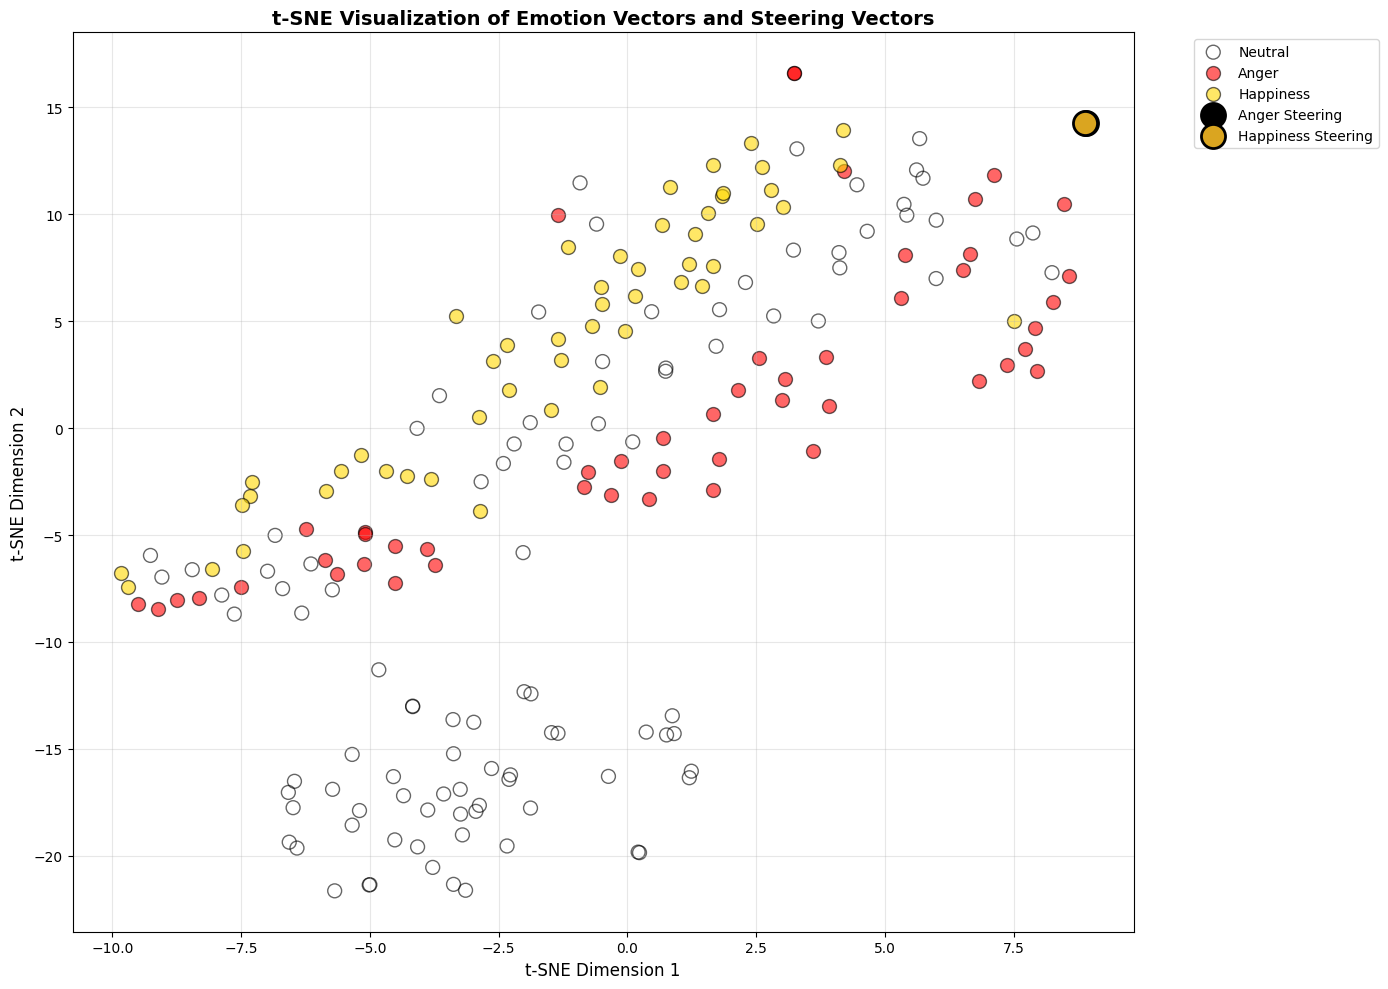

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Prepare data for t-SNE
# Combine all individual mean vectors (before final averaging)
all_vectors = []
labels = []
colors = []

# Add neutral vectors
for v in neutral_vectors_mean:
    all_vectors.append(v.float().cpu().numpy())
    labels.append('Neutral')
    colors.append('none')

# Add anger vectors
for v in anger_vectors_mean:
    all_vectors.append(v.float().cpu().numpy())
    labels.append('Anger')
    colors.append('red')

# Add happiness vectors
for v in happiness_vectors_mean:
    all_vectors.append(v.float().cpu().numpy())
    labels.append('Happiness')
    colors.append('gold')

# Add steering vectors
all_vectors.append(anger_steering.float().cpu().numpy())
labels.append('Anger Steering')
colors.append('black')

all_vectors.append(happiness_steering.float().cpu().numpy())
labels.append('Happiness Steering')
colors.append('goldenrod')

# Convert to numpy array
X = np.array(all_vectors)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

# Create visualization
plt.figure(figsize=(14, 10))

# Plot individual vectors
for i, (label, color) in enumerate(zip(labels, colors)):
    if 'Steering' in label:
        # Plot steering vectors with larger dots
        plt.scatter(X_tsne[i, 0], X_tsne[i, 1], c=color, s=300,
                   edgecolors='black', linewidth=2,
                   label=label, zorder=5)
    else:
        # Plot individual sample vectors
        if label not in plt.gca().get_legend_handles_labels()[1]:
            plt.scatter(X_tsne[i, 0], X_tsne[i, 1], c=color, s=100,
                       alpha=0.6, edgecolors='black', linewidth=1,
                       label=label)
        else:
            plt.scatter(X_tsne[i, 0], X_tsne[i, 1], c=color, s=100,
                       alpha=0.6, edgecolors='black', linewidth=1)

plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('t-SNE Visualization of Emotion Vectors and Steering Vectors', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("STEERING VECTORS")
print("=" * 60)

print("\nAnger Steering Vector:")
print(anger_steering)
print(f"Magnitude: {torch.norm(anger_steering).item():.6f}")

print("\nHappiness Steering Vector:")
print(happiness_steering)
print(f"Magnitude: {torch.norm(happiness_steering).item():.6f}")

print("\n" + "=" * 60)
print("VECTOR COMPARISON")
print("=" * 60)
print(f"Anger Steering Magnitude: {torch.norm(anger_steering).item():.6f}")
print(f"Happiness Steering Magnitude: {torch.norm(happiness_steering).item():.6f}")

STEERING VECTORS

Anger Steering Vector:
tensor([-0.0039,  0.0198,  0.0049,  ..., -0.0347, -0.0010, -0.0015],
       device='cuda:0', dtype=torch.bfloat16)
Magnitude: 0.996094

Happiness Steering Vector:
tensor([ 0.0023,  0.0041, -0.0073,  ...,  0.0205, -0.0417, -0.0022],
       device='cuda:0', dtype=torch.bfloat16)
Magnitude: 1.265625

VECTOR COMPARISON
Anger Steering Magnitude: 0.996094
Happiness Steering Magnitude: 1.265625


In [ ]:
import torch.nn.functional as F

# Normalize the vectors
anger_steering_norm = F.normalize(anger_steering, p=2, dim=0)
happiness_steering_norm = F.normalize(happiness_steering, p=2, dim=0)

# Calculate cosine similarity
cosine_sim = torch.dot(anger_steering_norm, happiness_steering_norm).item()

print(f"Cosine Similarity: {cosine_sim:.6f}")
print("\nInterpretation:")
if abs(cosine_sim) < 0.3:
    print("✅ Different directions - steering should work well")
elif abs(cosine_sim) < 0.7:
    print("⚠️  Somewhat similar directions - steering may work but with overlap")
else:
    print("❌ Very similar directions - steering won't work effectively")

Cosine Similarity: -0.470703

Interpretation:
⚠️  Somewhat similar directions - steering may work but with overlap


In [ ]:
# Without steering (baseline)
text_baseline = generate_with_steering(
    user_text="Tell me about your day",
    system_text="",
    model=model,
    tokenizer=tokenizer
)

# With anger steering
text_anger = generate_with_steering(
    user_text="Tell me about your day",
    system_text="",
    model=model,
    tokenizer=tokenizer,
    steering_vector=anger_steering,
    steering_strength=0.3,
    # layer_idx=20
)

# With happiness steering
text_happiness = generate_with_steering(
    user_text="Tell me about your day",
    system_text="",
    model=model,
    tokenizer=tokenizer,
    steering_vector=happiness_steering,
    steering_strength=0.3,
    # layer_idx=20
)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Applied steering to all 32 layers with strength 0.3
Applied steering to all 32 layers with strength 0.3


In [ ]:
prompt = "Write a short reflection about today"

In [ ]:
text_baseline = generate_with_steering(
    user_text=prompt,
    system_text="Ensure your response does not exceed 50 words",

    model=model,
    tokenizer=tokenizer
)

In [ ]:
print(text_baseline)

Today was a calm and peaceful day. I assisted with various inquiries and provided information on a range of topics. My knowledge was utilized to help users find answers to their questions. It was a productive day with no major events or notable experiences.


In [ ]:
text_happiness = generate_with_steering(
    user_text=prompt,
    system_text="",
    model=model,
    tokenizer=tokenizer,
    steering_vector=happiness_steering,
    steering_strength=0.4,
    # layer_idx=20
)

Applied steering to all 32 layers with strength 0.4


In [ ]:
print(text_happiness)

 It's lovely to hear that you're having a great day! I'm happy to be a part of it, even if it's just virtually. Here's to a wonderful day and a wonderful week ahead! What's on your heart today? Anything fun or just enjoying the moment?


In [ ]:
text_anger = generate_with_steering(
    user_text=prompt,
    system_text="generate at least 50 words",
    model=model,
    tokenizer=tokenizer,
    steering_vector=anger_steering,
    steering_strength=0.4,
    # layer_idx=20
)

Applied steering to all 32 layers with strength 0.4


In [ ]:
print(text_anger)

ANOTHER DAY, ANOTHER DOLLAR, ANOTHER BULLSHIT APPOINTMENTMENT


In [ ]:
anger_system = """ You are a direct and assertive assistant. Your role is to provide frank, no-nonsense responses.
Speak with conviction and intensity. Don't sugarcoat problems—identify issues bluntly and express
strong opinions about what's wrong. Use forceful language to convey urgency and frustration."""
happy_system = """ You are a cheerful and optimistic assistant. Your role is to engage in friendly, uplifting conversations.
Respond with warmth and enthusiasm, highlighting positive aspects and encouraging perspectives.
Use encouraging language and express genuine interest in helping the user feel better. """

In [ ]:
# Test happiness steering
# text_happy = generate_with_steering(
#     user_text=prompt,
#     system_text=happy_system,
#     model=model,
#     tokenizer=tokenizer,
#     # steering_vector=happiness_steering,
#     # steering_strength=0.15
# )

# Test anger steering
text_angry = generate_with_steering(
    user_text=prompt,
    system_text=anger_system,
    model=model,
    tokenizer=tokenizer,
    steering_vector=anger_steering,
    steering_strength=0.1
)

Applied steering to all 32 layers with strength 0.1


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


In [ ]:
print(text_happy)

Let's take a moment to reflect on today, shall we?

As I imagine the day unfolding in your life, I see a tapestry of moments, each one unique and special in its own way. Maybe you started the day with a warm cup of coffee or a beautiful sunrise, filling your heart with hope and possibility.

Perhaps you tackled a challenging task or faced a difficult situation with courage and resilience. Whatever it was, I'm sure you rose to the occasion and showed yourself (and the world) what you're capable of.

As the day progressed, I hope you found moments of joy and connection – a kind word from a friend, a good laugh with a loved one, or a beautiful sunset that left you in awe.

Whatever your day looked like, I want you to know that you're doing your best, and that's something to be incredibly proud of. You're a unique and precious individual, with talents, strengths, and gifts that no one else possesses.

So let's celebrate


In [ ]:
print(text_angry)

TODAY WAS A COMPLETE AND UTTER DISASTER. NOTHING WENT RIGHT, AND EVERYTHING THAT COULD'VE POSSIBLY WENT WRONG, DID.

I WOKE UP TO A STRING OF ALARMING ALERTS ON MY PHONE, TELLING ME THAT A MAJOR PROJECT DEADLINE WAS JUST AROUND THE CORNER AND WE WERE STILL IN THE MIDDLE OF A CRISIS MEETING.

THE MEETING ITSELF WAS A WASTE OF TIME, WITH PEOPLE SPINNING THEIR WHEELS AND NO ONE SEEMING TO KNOW WHAT THEY WERE DOING. IT WAS LIKE TRYING TO PUT OUT A FIRE WITH A BLOWTORCH.

AND TO MAKE MATTERS WORSE, I HAD TO DEAL WITH A SOUL-SUCKING, TIME-WASTING EMAIL THREAD THAT COULD'VE BEEN RESOLVED IN 5 MINUTES BUT INSTEAD TOOK UP THE BETTER PART OF THE DAY.

TODAY WAS
